AI-Powered Hotel Booking Cancellation Prediction
and Revenue Protection System

In [1]:
!pip install -q xgboost lightgbm shap optuna imbalanced-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 12.0 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap
import warnings

warnings.filterwarnings("ignore")

In [4]:
from google.colab import files

uploaded = files.upload()

Saving hotel_bookings.csv to hotel_bookings.csv


In [5]:
df = pd.read_csv("hotel_bookings.csv")

In [6]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [7]:
df.shape

(119390, 32)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [9]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [10]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [11]:
df["is_canceled"].value_counts()

,count
is_canceled,
0,75166
1,44224


In [12]:
df["is_canceled"].value_counts(normalize=True) * 100

,proportion
is_canceled,
0,62.958372
1,37.041628


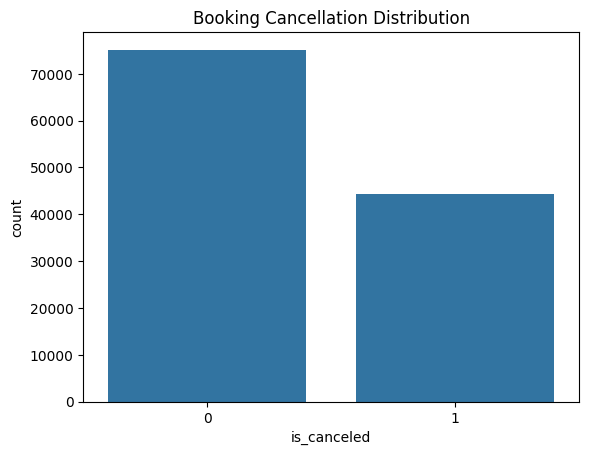

In [13]:
sns.countplot(data=df, x="is_canceled")
plt.title("Booking Cancellation Distribution")
plt.show()

In [14]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

,0
company,112593
agent,16340
country,488
children,4


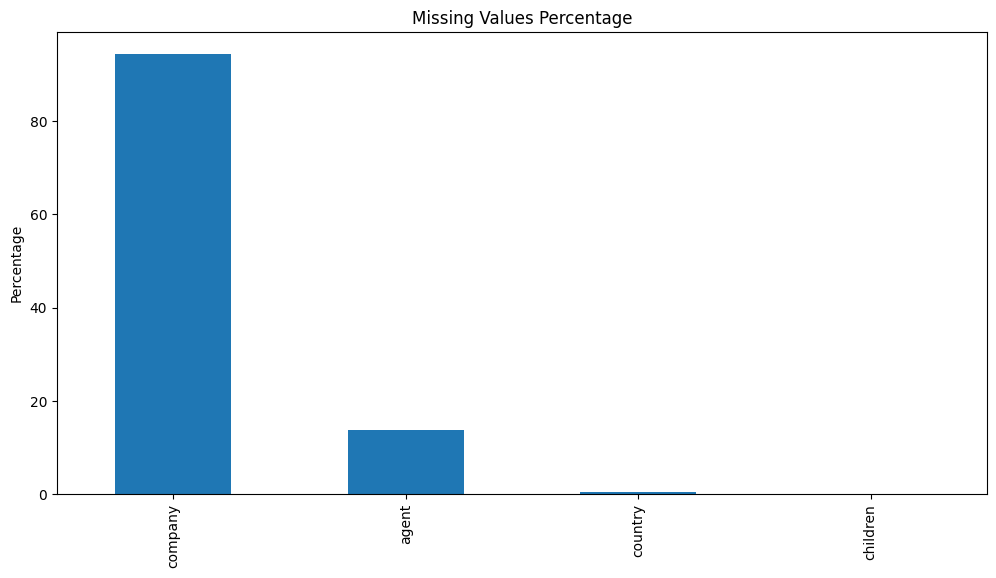

In [15]:
plt.figure(figsize=(12,6))

missing_percent = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percent[missing_percent > 0].plot(kind="bar")

plt.title("Missing Values Percentage")
plt.ylabel("Percentage")
plt.show()

In [16]:
drop_columns = [
    "reservation_status",
    "reservation_status_date"
]

df = df.drop(columns=drop_columns)

In [17]:
df["children"].isnull().sum()

np.int64(4)

In [18]:
df["children"] = df["children"].fillna(0)

In [19]:
df["country"] = df["country"].fillna("Unknown")

In [20]:
df["agent"] = df["agent"].fillna(0)

In [21]:
df["company"] = df["company"].fillna(0)

In [27]:
df[df["adults"] == 0].shape

(223, 30)

In [28]:
df[
    (df["adults"] == 0) &
    (df["children"] == 0) &
    (df["babies"] == 0)
].shape

(0, 30)

In [30]:
df["total_guests"] = (
    df["adults"] +
    df["children"] +
    df["babies"]
)

In [31]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'total_guests'],
      dtype='object')

In [32]:
df["total_guests"].describe()

,total_guests
count,119210.000000
mean,1.971210
std,0.718876
min,1.000000
25%,2.000000
50%,2.000000
75%,2.000000
max,55.000000


In [33]:
df[df["total_guests"] == 0].shape

(0, 31)

In [34]:
df["total_nights"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
)

In [35]:
df["total_nights"].describe()

,total_nights
count,119210.000000
mean,3.426248
std,2.540692
min,0.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,69.000000


In [36]:
df[df["total_nights"] == 0].shape

(645, 32)

In [37]:
df[df["total_nights"] == 0][
    [
        "hotel",
        "is_canceled",
        "adults",
        "children",
        "babies",
        "total_nights",
        "adr"
    ]
].head(10)

,hotel,is_canceled,adults,children,babies,total_nights,adr
0,Resort Hotel,0,2,0.0,0,0,0.0
1,Resort Hotel,0,2,0.0,0,0,0.0
167,Resort Hotel,0,2,0.0,0,0,0.0
168,Resort Hotel,0,1,0.0,0,0,0.0
196,Resort Hotel,0,2,0.0,0,0,0.0
197,Resort Hotel,0,2,0.0,0,0,0.0
459,Resort Hotel,0,2,0.0,0,0,0.0
568,Resort Hotel,0,1,0.0,0,0,0.0
569,Resort Hotel,0,2,0.0,0,0,0.0
618,Resort Hotel,0,2,2.0,0,0,0.0


In [38]:
df[df["total_nights"] == 0].shape

(645, 32)

In [39]:
df[df["total_nights"] == 0]["is_canceled"].value_counts()

,count
is_canceled,
0,622
1,23


In [40]:
zero_night_percent = (
    (df["total_nights"] == 0).mean() * 100
)

print("Zero-night bookings:", zero_night_percent, "%")

Zero-night bookings: 0.5410619914436708 %


In [41]:
df = df[df["total_nights"] > 0].copy()

In [42]:
df.shape

(118565, 32)

In [43]:
df["estimated_booking_value"] = (
    df["adr"] * df["total_nights"]
)

In [44]:
df["estimated_booking_value"].describe()

,estimated_booking_value
count,118565.000000
mean,360.259346
std,335.774256
min,-63.800000
25%,150.000000
50%,268.000000
75%,448.020000
max,7590.000000


In [45]:
df[
    [
        "hotel",
        "total_nights",
        "adr",
        "estimated_booking_value",
        "is_canceled"
    ]
].sort_values(
    "estimated_booking_value",
    ascending=False
).head(10)

,hotel,total_nights,adr,estimated_booking_value,is_canceled
14038,Resort Hotel,69,110.00,7590.00,0
14037,Resort Hotel,60,110.50,6630.00,0
13142,Resort Hotel,14,450.00,6300.00,1
60133,City Hotel,29,212.00,6148.00,1
48515,City Hotel,1,5400.00,5400.00,1
60747,City Hotel,29,171.30,4967.70,1
64375,City Hotel,21,231.81,4868.01,1
27242,Resort Hotel,14,318.00,4452.00,0
62583,City Hotel,30,140.00,4200.00,1
60780,City Hotel,28,147.90,4141.20,1


In [46]:
df["is_long_stay"] = (
    df["total_nights"] >= 7
).astype(int)

In [47]:
df["is_long_stay"].value_counts()

,count
is_long_stay,
0,104691
1,13874


In [48]:
pd.crosstab(
    df["is_long_stay"],
    df["is_canceled"],
    normalize="index"
) * 100

is_canceled,0,1
is_long_stay,,
0,62.433256,37.566744
1,65.064149,34.935851


In [49]:
median_booking_value = df["estimated_booking_value"].median()

print("Median Booking Value:", median_booking_value)

Median Booking Value: 268.0


In [50]:
df["is_high_value_booking"] = (
    df["estimated_booking_value"] >= median_booking_value
).astype(int)

In [51]:
df["is_high_value_booking"].value_counts()

,count
is_high_value_booking,
1,59321
0,59244


In [52]:
pd.crosstab(
    df["is_high_value_booking"],
    df["is_canceled"],
    normalize="index"
) * 100

is_canceled,0,1
is_high_value_booking,,
0,64.190467,35.809533
1,61.293640,38.706360


In [53]:
df["has_previous_cancellation"] = (
    df["previous_cancellations"] > 0
).astype(int)

In [54]:
df["has_previous_cancellation"].value_counts()

,count
has_previous_cancellation,
0,112090
1,6475


In [55]:
pd.crosstab(
    df["has_previous_cancellation"],
    df["is_canceled"],
    normalize="index"
) * 100

is_canceled,0,1
has_previous_cancellation,,
0,65.888126,34.111874
1,8.262548,91.737452


In [56]:
df["has_booking_changes"] = (
    df["booking_changes"] > 0
).astype(int)

In [57]:
df["has_booking_changes"].value_counts()

,count
has_booking_changes,
0,100714
1,17851


In [58]:
pd.crosstab(
    df["has_booking_changes"],
    df["is_canceled"],
    normalize="index"
) * 100

is_canceled,0,1
has_booking_changes,,
0,58.942153,41.057847
1,84.174556,15.825444


In [59]:
df["has_special_request"] = (
    df["total_of_special_requests"] > 0
).astype(int)

In [60]:
df["has_special_request"].value_counts()

,count
has_special_request,
0,69800
1,48765


In [61]:
pd.crosstab(
    df["has_special_request"],
    df["is_canceled"],
    normalize="index"
) * 100

is_canceled,0,1
has_special_request,,
0,51.975645,48.024355
1,78.150313,21.849687


In [62]:
df["has_weekend_stay"] = (
    df["stays_in_weekend_nights"] > 0
).astype(int)

In [63]:
df["has_weekend_stay"].value_counts()

,count
has_weekend_stay,
1,67315
0,51250


In [64]:
pd.crosstab(
    df["has_weekend_stay"],
    df["is_canceled"],
    normalize="index"
) * 100

is_canceled,0,1
has_weekend_stay,,
0,62.025366,37.974634
1,63.286043,36.713957


In [65]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 118565
Number of columns: 39


In [66]:
new_features = [
    "total_guests",
    "total_nights",
    "estimated_booking_value",
    "is_long_stay",
    "is_high_value_booking",
    "has_previous_cancellation",
    "has_booking_changes",
    "has_special_request",
    "has_weekend_stay"
]

df[new_features].head()

,total_guests,total_nights,estimated_booking_value,is_long_stay,is_high_value_booking,has_previous_cancellation,has_booking_changes,has_special_request,has_weekend_stay
2,1.0,1,75.0,0,0,0,0,0,0
3,1.0,1,75.0,0,0,0,0,0,0
4,2.0,2,196.0,0,0,0,0,1,0
5,2.0,2,196.0,0,0,0,0,1,0
6,2.0,2,214.0,0,0,0,0,0,0


In [67]:
df[new_features].isnull().sum()

,0
total_guests,0
total_nights,0
estimated_booking_value,0
is_long_stay,0
is_high_value_booking,0
has_previous_cancellation,0
has_booking_changes,0
has_special_request,0
has_weekend_stay,0


In [68]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 32184


In [69]:
print("Before removing duplicates:", df.shape)

Before removing duplicates: (118565, 39)


In [70]:
df = df.drop_duplicates().copy()

In [71]:
print("After removing duplicates:", df.shape)

After removing duplicates: (86381, 39)


In [72]:
print("Remaining duplicates:", df.duplicated().sum())

Remaining duplicates: 0


In [74]:
df = df.drop(
    columns=[
        "reservation_status",
        "reservation_status_date"
    ],
    errors="ignore"
)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 86381
Columns: 39


In [75]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(
    ascending=False
)

print(missing)

Series([], dtype: int64)


In [76]:
print(df["is_canceled"].value_counts())

is_canceled
0    62653
1    23728
Name: count, dtype: int64


In [77]:
print(
    df["is_canceled"]
    .value_counts(normalize=True) * 100
)

is_canceled
0    72.530996
1    27.469004
Name: proportion, dtype: float64


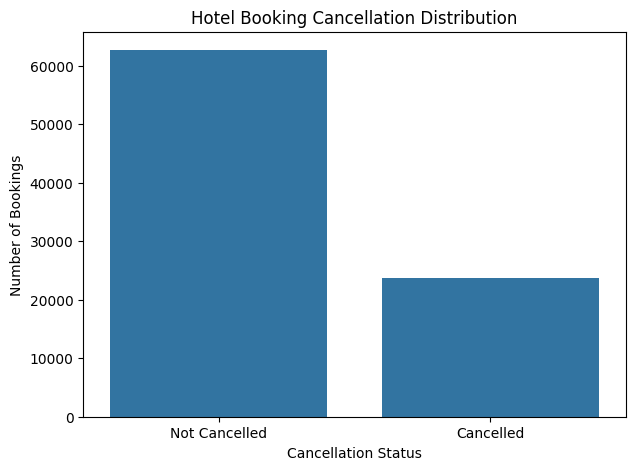

In [78]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="is_canceled"
)

plt.title("Hotel Booking Cancellation Distribution")
plt.xlabel("Cancellation Status")
plt.ylabel("Number of Bookings")

plt.xticks(
    [0, 1],
    ["Not Cancelled", "Cancelled"]
)

plt.show()

In [79]:
hotel_cancel_rate = (
    df.groupby("hotel")["is_canceled"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

print(hotel_cancel_rate)

hotel
City Hotel      29.974654
Resort Hotel    23.516247
Name: is_canceled, dtype: float64


In [82]:
X = df.drop(columns=["is_canceled"]).copy()
y = df["is_canceled"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (86381, 38)
y shape: (86381,)


In [83]:
print("Numerical columns:")
print(X.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical columns:")
print(X.select_dtypes(include=["object"]).columns.tolist())

Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_guests', 'total_nights', 'estimated_booking_value', 'is_long_stay', 'is_high_value_booking', 'has_previous_cancellation', 'has_booking_changes', 'has_special_request', 'has_weekend_stay']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 69104
Testing rows: 17277


In [85]:
print("Training cancellation rate:")
print(y_train.mean() * 100)

print("\nTesting cancellation rate:")
print(y_test.mean() * 100)

Training cancellation rate:
27.468742764528827

Testing cancellation rate:
27.47004688313943


In [86]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (86381, 38)
y shape: (86381,)


In [87]:
print("Training cancellation rate:", y_train.mean() * 100)
print("Testing cancellation rate:", y_test.mean() * 100)

Training cancellation rate: 27.468742764528827
Testing cancellation rate: 27.47004688313943


In [88]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Number of numerical features:", len(numeric_features))
print("Numerical features:")
print(numeric_features)

print("\nNumber of categorical features:", len(categorical_features))
print("Categorical features:")
print(categorical_features)

Number of numerical features: 28
Numerical features:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_guests', 'total_nights', 'estimated_booking_value', 'is_long_stay', 'is_high_value_booking', 'has_previous_cancellation', 'has_booking_changes', 'has_special_request', 'has_weekend_stay']

Number of categorical features: 10
Categorical features:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


In [89]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [90]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

In [91]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [92]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [93]:
from sklearn.linear_model import LogisticRegression

In [94]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

In [95]:
logistic_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                                                   'babies',
                                                   'is_repeated_guest',
                                                   'previous_cancellations',
                                                   '...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['hotel',
                                                   'arrival_date_month', 'meal',
                                                   'country', 'market_segment',
                                                   'distribution_channel',
                                                   'reserved_room_type',
                                                   'assigned_room_type',
                                                   'deposit_type',
                                                   'customer_type'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [96]:
print("Logistic Regression training completed!")

Logistic Regression training completed!


In [97]:
y_pred_logistic = logistic_model.predict(X_test)

y_prob_logistic = (
    logistic_model.predict_proba(X_test)[:, 1]
)

In [98]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [99]:
print("Logistic Regression Results")
print("--------------------------------")

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_logistic)
)

print(
    "Precision:",
    precision_score(y_test, y_pred_logistic)
)

print(
    "Recall:",
    recall_score(y_test, y_pred_logistic)
)

print(
    "F1 Score:",
    f1_score(y_test, y_pred_logistic)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_logistic)
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test,
        y_prob_logistic
    )
)

Logistic Regression Results
--------------------------------
Accuracy: 0.7431267002373098
Precision: 0.522627093740817
Recall: 0.7494732406236831
F1 Score: 0.6158240997229917
ROC-AUC: 0.8246504084955698
PR-AUC: 0.6285312400072756


In [7]:
from sklearn.ensemble import RandomForestClassifier

In [10]:
import os

print(os.listdir("/content"))

['.config', 'sample_data']


In [14]:
from google.colab import files

uploaded = files.upload()

Saving hotel_bookings.csv to hotel_bookings.csv


In [15]:
import pandas as pd

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("File loaded:", filename)
print("Dataset shape:", df.shape)

File loaded: hotel_bookings.csv
Dataset shape: (119390, 32)


In [16]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [17]:
print(df.shape)
print(df.columns.tolist())

(119390, 32)
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


In [18]:
print(df.shape)

(119390, 32)


In [20]:
import pandas as pd

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("File loaded:", filename)
print("Dataset shape:", df.shape)

File loaded: hotel_bookings.csv
Dataset shape: (119390, 32)


In [21]:
print(df.shape)

(119390, 32)


In [22]:
# ============================================
# HOTEL CANCELLATION PROJECT - CLEANING
# ============================================

# 1. Remove exact duplicate rows
df = df.drop_duplicates().copy()

# 2. Convert children missing values to 0
df["children"] = df["children"].fillna(0)

# 3. Convert children to numeric
df["children"] = pd.to_numeric(
    df["children"],
    errors="coerce"
).fillna(0)

# 4. Create total guests
df["total_guests"] = (
    df["adults"] +
    df["children"] +
    df["babies"]
)

# 5. Create total nights
df["total_nights"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
)

# 6. Remove zero-night bookings
df = df[df["total_nights"] > 0].copy()

# 7. Create estimated booking value
df["estimated_booking_value"] = (
    df["adr"] * df["total_nights"]
)

# 8. Long-stay feature
df["is_long_stay"] = (
    df["total_nights"] >= 7
).astype(int)

# 9. High-value booking feature
median_booking_value = df[
    "estimated_booking_value"
].median()

df["is_high_value_booking"] = (
    df["estimated_booking_value"] >= median_booking_value
).astype(int)

# 10. Previous cancellation feature
df["has_previous_cancellation"] = (
    df["previous_cancellations"] > 0
).astype(int)

# 11. Booking changes feature
df["has_booking_changes"] = (
    df["booking_changes"] > 0
).astype(int)

# 12. Special request feature
df["has_special_request"] = (
    df["total_of_special_requests"] > 0
).astype(int)

# 13. Weekend stay feature
df["has_weekend_stay"] = (
    df["stays_in_weekend_nights"] > 0
).astype(int)

# 14. Remove leakage columns
df = df.drop(
    columns=[
        "reservation_status",
        "reservation_status_date"
    ],
    errors="ignore"
)

print("Cleaning completed!")
print("Final shape:", df.shape)
print("Duplicates:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())

Cleaning completed!
Final shape: (86745, 39)
Duplicates: 258
Missing values: 93998


In [23]:
print(df.shape)

(86745, 39)


In [24]:
# ============================================
# PREPARE DATA FOR MACHINE LEARNING
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Target and features
X = df.drop(columns=["is_canceled"]).copy()
y = df["is_canceled"].copy()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Identify column types
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("X:", X.shape)
print("Training:", X_train.shape)
print("Testing:", X_test.shape)
print("Numerical columns:", len(numeric_features))
print("Categorical columns:", len(categorical_features))

X: (86745, 38)
Training: (69396, 38)
Testing: (17349, 38)
Numerical columns: 28
Categorical columns: 10


In [25]:
# ============================================
# PREPROCESSING PIPELINE
# ============================================

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessor ready!")

Preprocessor ready!


In [26]:
# ============================================
# RANDOM FOREST
# ============================================

from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest ready!")

Random Forest ready!


In [27]:
rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [28]:
# ============================================
# RANDOM FOREST PREDICTIONS
# ============================================

y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Predictions completed!")
print("Number of predictions:", len(y_pred_rf))

Predictions completed!
Number of predictions: 17349


In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("RANDOM FOREST RESULTS")
print("=" * 40)

print("Accuracy :", round(
    accuracy_score(y_test, y_pred_rf), 4
))

print("Precision:", round(
    precision_score(y_test, y_pred_rf), 4
))

print("Recall   :", round(
    recall_score(y_test, y_pred_rf), 4
))

print("F1 Score :", round(
    f1_score(y_test, y_pred_rf), 4
))

print("ROC-AUC  :", round(
    roc_auc_score(y_test, y_prob_rf), 4
))

print("PR-AUC   :", round(
    average_precision_score(y_test, y_prob_rf), 4
))

RANDOM FOREST RESULTS
Accuracy : 0.8468
Precision: 0.78
Recall   : 0.6214
F1 Score : 0.6917
ROC-AUC  : 0.9091
PR-AUC   : 0.7996


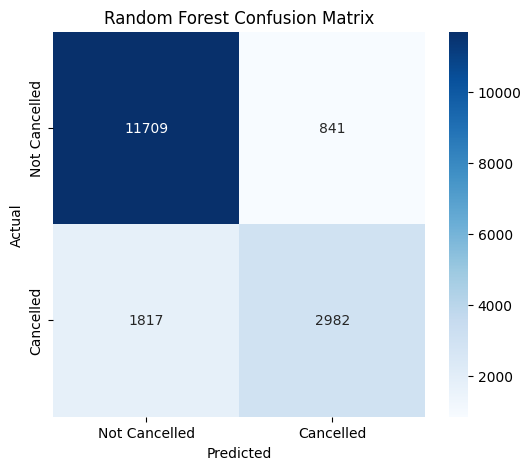

In [30]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Cancelled", "Cancelled"],
    yticklabels=["Not Cancelled", "Cancelled"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [31]:
!pip -q install xgboost

In [32]:
from xgboost import XGBClassifier

In [33]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=6,
                min_child_weight=2,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("XGBoost model ready!")

XGBoost model ready!


In [34]:
xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost training completed!")

XGBoost training completed!


In [35]:
# ============================================
# XGBOOST PREDICTIONS
# ============================================

y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost predictions completed!")
print("Number of predictions:", len(y_pred_xgb))

XGBoost predictions completed!
Number of predictions: 17349


In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("XGBOOST RESULTS")
print("=" * 40)

print("Accuracy :", round(
    accuracy_score(y_test, y_pred_xgb), 4
))

print("Precision:", round(
    precision_score(y_test, y_pred_xgb), 4
))

print("Recall   :", round(
    recall_score(y_test, y_pred_xgb), 4
))

print("F1 Score :", round(
    f1_score(y_test, y_pred_xgb), 4
))

print("ROC-AUC  :", round(
    roc_auc_score(y_test, y_prob_xgb), 4
))

print("PR-AUC   :", round(
    average_precision_score(y_test, y_prob_xgb), 4
))

XGBOOST RESULTS
Accuracy : 0.8528
Precision: 0.7568
Recall   : 0.6893
F1 Score : 0.7215
ROC-AUC  : 0.9202
PR-AUC   : 0.8202


In [37]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1": [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_xgb)
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest,0.8468,0.7800,0.6214,0.6917,0.9091,0.7996
1,XGBoost,0.8528,0.7568,0.6893,0.7215,0.9202,0.8202


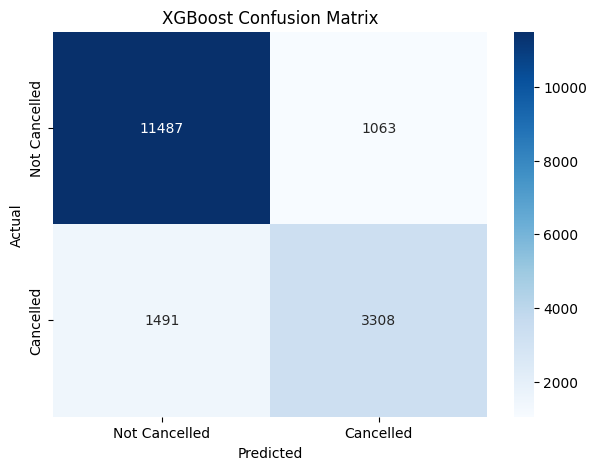

In [38]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Cancelled", "Cancelled"],
    yticklabels=["Not Cancelled", "Cancelled"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

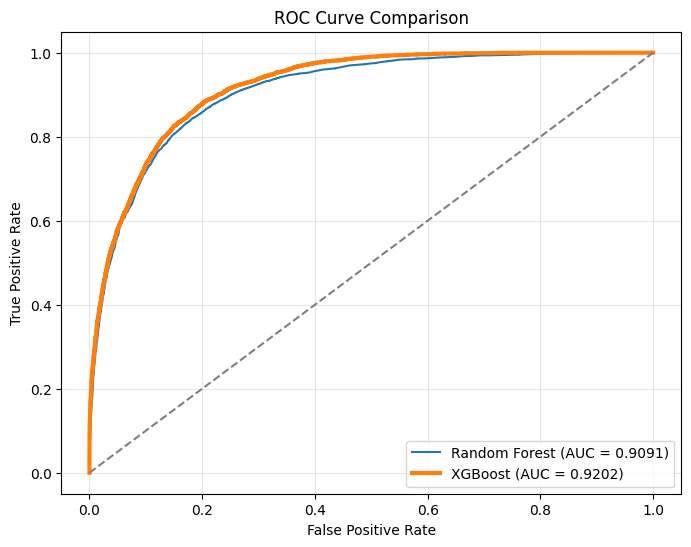

In [39]:
from sklearn.metrics import roc_curve

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_prob_xgb
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label="Random Forest (AUC = 0.9091)"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label="XGBoost (AUC = 0.9202)",
    linewidth=3
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [40]:
xgb_model.predict(X_test)

array([1, 0, 0, ..., 0, 0, 0])

In [41]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

threshold_results = []

for threshold in np.arange(0.20, 0.81, 0.01):

    y_pred_threshold = (
        y_prob_xgb >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        ),
        "f1": f1_score(
            y_test,
            y_pred_threshold,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df.sort_values(
    "f1",
    ascending=False
).head(10)

,threshold,precision,recall,f1
19,0.39,0.703012,0.792665,0.745152
18,0.38,0.695385,0.800583,0.744285
17,0.37,0.689545,0.808085,0.744124
16,0.36,0.682490,0.817879,0.744076
15,0.35,0.675234,0.826631,0.743301
20,0.40,0.707345,0.782663,0.743100
21,0.41,0.713134,0.773911,0.742280
14,0.34,0.668281,0.833715,0.741888
22,0.42,0.718738,0.764118,0.740733
23,0.43,0.724441,0.755991,0.739880


In [42]:
threshold_df.sort_values(
    "f1",
    ascending=False
).head(10)

,threshold,precision,recall,f1
19,0.39,0.703012,0.792665,0.745152
18,0.38,0.695385,0.800583,0.744285
17,0.37,0.689545,0.808085,0.744124
16,0.36,0.682490,0.817879,0.744076
15,0.35,0.675234,0.826631,0.743301
20,0.40,0.707345,0.782663,0.743100
21,0.41,0.713134,0.773911,0.742280
14,0.34,0.668281,0.833715,0.741888
22,0.42,0.718738,0.764118,0.740733
23,0.43,0.724441,0.755991,0.739880


In [43]:
best_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

best_threshold = best_row["threshold"]

print("Best threshold:", best_threshold)
print("Precision:", best_row["precision"])
print("Recall:", best_row["recall"])
print("F1:", best_row["f1"])

Best threshold: 0.3900000000000002
Precision: 0.7030123821844391
Recall: 0.7926651385705356
F1: 0.7451518119490695


In [44]:
y_pred_xgb_optimized = (
    y_prob_xgb >= best_threshold
).astype(int)

print("Optimized predictions created!")

Optimized predictions created!


In [45]:
print("OPTIMIZED XGBOOST")
print("=" * 40)

print("Threshold :", round(best_threshold, 2))
print("Precision :", round(
    precision_score(y_test, y_pred_xgb_optimized), 4
))
print("Recall    :", round(
    recall_score(y_test, y_pred_xgb_optimized), 4
))
print("F1 Score  :", round(
    f1_score(y_test, y_pred_xgb_optimized), 4
))
print("ROC-AUC   :", round(
    roc_auc_score(y_test, y_prob_xgb), 4
))
print("PR-AUC    :", round(
    average_precision_score(y_test, y_prob_xgb), 4
))

OPTIMIZED XGBOOST
Threshold : 0.39
Precision : 0.703
Recall    : 0.7927
F1 Score  : 0.7452
ROC-AUC   : 0.9202
PR-AUC    : 0.8202


In [46]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb_tuning = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("Tuning model created!")

Tuning model created!


In [47]:
param_grid = {
    "classifier__n_estimators": [
        300, 500, 700
    ],

    "classifier__learning_rate": [
        0.03, 0.05, 0.08, 0.10
    ],

    "classifier__max_depth": [
        4, 5, 6, 7
    ],

    "classifier__min_child_weight": [
        1, 2, 5
    ],

    "classifier__subsample": [
        0.7, 0.8, 0.9
    ],

    "classifier__colsample_bytree": [
        0.7, 0.8, 0.9
    ]
}

print("Parameter grid created!")

Parameter grid created!


In [48]:
random_search = RandomizedSearchCV(
    estimator=xgb_tuning,
    param_distributions=param_grid,
    n_iter=15,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Randomized search ready!")

Randomized search ready!


In [49]:
random_search.fit(
    X_train,
    y_train
)

print("Hyperparameter tuning completed!")

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Hyperparameter tuning completed!


In [50]:
print("Best ROC-AUC:")
print(random_search.best_score_)

print("\nBest parameters:")
print(random_search.best_params_)

Best ROC-AUC:
0.9183799937414895

Best parameters:
{'classifier__subsample': 0.8, 'classifier__n_estimators': 700, 'classifier__min_child_weight': 1, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.8}


In [51]:
best_xgb_model = random_search.best_estimator_

y_pred_tuned = best_xgb_model.predict(X_test)
y_prob_tuned = best_xgb_model.predict_proba(X_test)[:, 1]

print("Tuned XGBoost predictions completed!")

Tuned XGBoost predictions completed!


In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

print("TUNED XGBOOST RESULTS")
print("=" * 45)

print("Accuracy :", round(accuracy_score(y_test, y_pred_tuned), 4))
print("Precision:", round(precision_score(y_test, y_pred_tuned), 4))
print("Recall   :", round(recall_score(y_test, y_pred_tuned), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_tuned), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_tuned), 4))
print("PR-AUC   :", round(average_precision_score(y_test, y_prob_tuned), 4))

TUNED XGBOOST RESULTS
Accuracy : 0.8572
Precision: 0.7623
Recall   : 0.7031
F1 Score : 0.7315
ROC-AUC  : 0.9238
PR-AUC   : 0.8267


In [53]:
model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_tuned)
    ],
    "Precision": [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_tuned)
    ],
    "Recall": [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_tuned)
    ],
    "F1": [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_tuned)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_tuned)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_xgb),
        average_precision_score(y_test, y_prob_tuned)
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest,0.8468,0.7800,0.6214,0.6917,0.9091,0.7996
1,XGBoost,0.8528,0.7568,0.6893,0.7215,0.9202,0.8202
2,Tuned XGBoost,0.8572,0.7623,0.7031,0.7315,0.9238,0.8267


In [54]:
threshold_results_tuned = []

for threshold in np.arange(0.20, 0.81, 0.01):

    pred = (y_prob_tuned >= threshold).astype(int)

    threshold_results_tuned.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test, pred, zero_division=0
        ),
        "recall": recall_score(
            y_test, pred, zero_division=0
        ),
        "f1": f1_score(
            y_test, pred, zero_division=0
        )
    })

threshold_tuned_df = pd.DataFrame(
    threshold_results_tuned
)

best_tuned_threshold = threshold_tuned_df.loc[
    threshold_tuned_df["f1"].idxmax()
]

print(best_tuned_threshold)

threshold    0.320000
precision    0.669895
recall       0.850385
f1           0.749426
Name: 12, dtype: float64


In [55]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    random_search.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("5-Fold Cross-Validation ROC-AUC")
print("=" * 40)

for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score:.4f}")

print("-" * 40)
print("Mean ROC-AUC:", round(cv_scores.mean(), 4))
print("Std ROC-AUC :", round(cv_scores.std(), 4))

5-Fold Cross-Validation ROC-AUC
Fold 1: 0.9211
Fold 2: 0.9229
Fold 3: 0.9181
Fold 4: 0.9207
Fold 5: 0.9210
----------------------------------------
Mean ROC-AUC: 0.9208
Std ROC-AUC : 0.0015


In [56]:
original_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

tuned_auc = roc_auc_score(
    y_test,
    y_prob_tuned
)

print("Original XGBoost ROC-AUC:", round(original_auc, 4))
print("Tuned XGBoost ROC-AUC   :", round(tuned_auc, 4))

if tuned_auc >= original_auc:
    final_model = best_xgb_model
    final_probabilities = y_prob_tuned
    final_model_name = "Tuned XGBoost"
else:
    final_model = xgb_model
    final_probabilities = y_prob_xgb
    final_model_name = "XGBoost"

print("\nFINAL MODEL:", final_model_name)

Original XGBoost ROC-AUC: 0.9202
Tuned XGBoost ROC-AUC   : 0.9238

FINAL MODEL: Tuned XGBoost


In [57]:
final_threshold_table = []

for threshold in np.arange(0.20, 0.81, 0.01):

    pred = (
        final_probabilities >= threshold
    ).astype(int)

    final_threshold_table.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test,
            pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_test,
            pred,
            zero_division=0
        )
    })

final_threshold_df = pd.DataFrame(
    final_threshold_table
)

best_final_row = final_threshold_df.loc[
    final_threshold_df["f1"].idxmax()
]

final_threshold = best_final_row["threshold"]

print("FINAL MODEL:", final_model_name)
print("FINAL THRESHOLD:", round(final_threshold, 2))
print("Precision:", round(best_final_row["precision"], 4))
print("Recall:", round(best_final_row["recall"], 4))
print("F1:", round(best_final_row["f1"], 4))

FINAL MODEL: Tuned XGBoost
FINAL THRESHOLD: 0.32
Precision: 0.6699
Recall: 0.8504
F1: 0.7494


In [58]:
final_predictions = (
    final_probabilities >= final_threshold
).astype(int)

print("Final predictions created!")

Final predictions created!


In [59]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=[
            "Not Cancelled",
            "Cancelled"
        ]
    )
)

               precision    recall  f1-score   support

Not Cancelled       0.94      0.84      0.89     12550
    Cancelled       0.67      0.85      0.75      4799

     accuracy                           0.84     17349
    macro avg       0.80      0.85      0.82     17349
 weighted avg       0.86      0.84      0.85     17349



In [60]:
!pip -q install shap

In [61]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SHAP ready!")

SHAP ready!


In [62]:
xgb_classifier = final_model.named_steps["classifier"]

print(type(xgb_classifier))

<class 'xgboost.sklearn.XGBClassifier'>


In [63]:
X_test_transformed = final_model.named_steps[
    "preprocessor"
].transform(X_test)

print("Transformed test data shape:", X_test_transformed.shape)

Transformed test data shape: (17349, 260)


In [64]:
explainer = shap.TreeExplainer(
    xgb_classifier
)

shap_values = explainer.shap_values(
    X_test_transformed
)

print("SHAP values calculated!")

SHAP values calculated!


In [65]:
feature_names = final_model.named_steps[
    "preprocessor"
].get_feature_names_out()

print("Number of features:", len(feature_names))

Number of features: 260


In [66]:
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "importance",
    ascending=False
)

shap_importance.head(20)

,feature,importance
178,categorical__country_PRT,0.840541
17,numeric__required_car_parking_spaces,0.640617
13,numeric__agent,0.521985
0,numeric__lead_time,0.487464
18,numeric__total_of_special_requests,0.420155
226,categorical__market_segment_Online TA,0.305730
1,numeric__arrival_date_year,0.233624
12,numeric__booking_changes,0.158651
258,categorical__customer_type_Transient,0.144573
242,categorical__assigned_room_type_A,0.122108


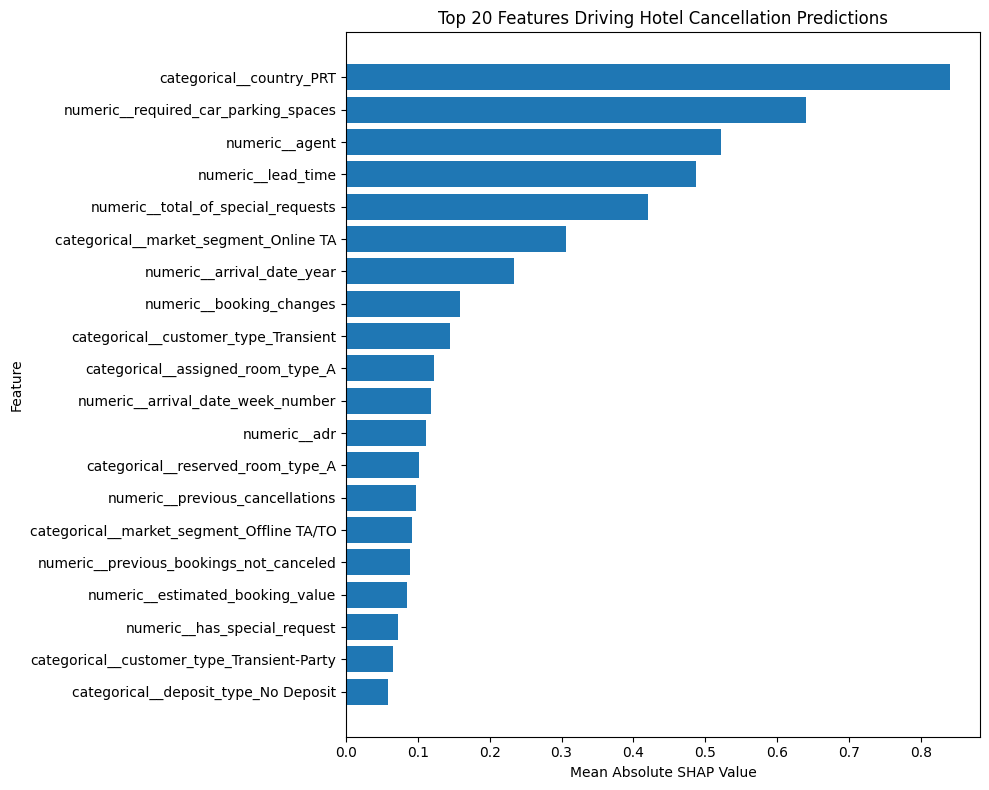

In [67]:
top_features = shap_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 20 Features Driving Hotel Cancellation Predictions")

plt.tight_layout()
plt.show()

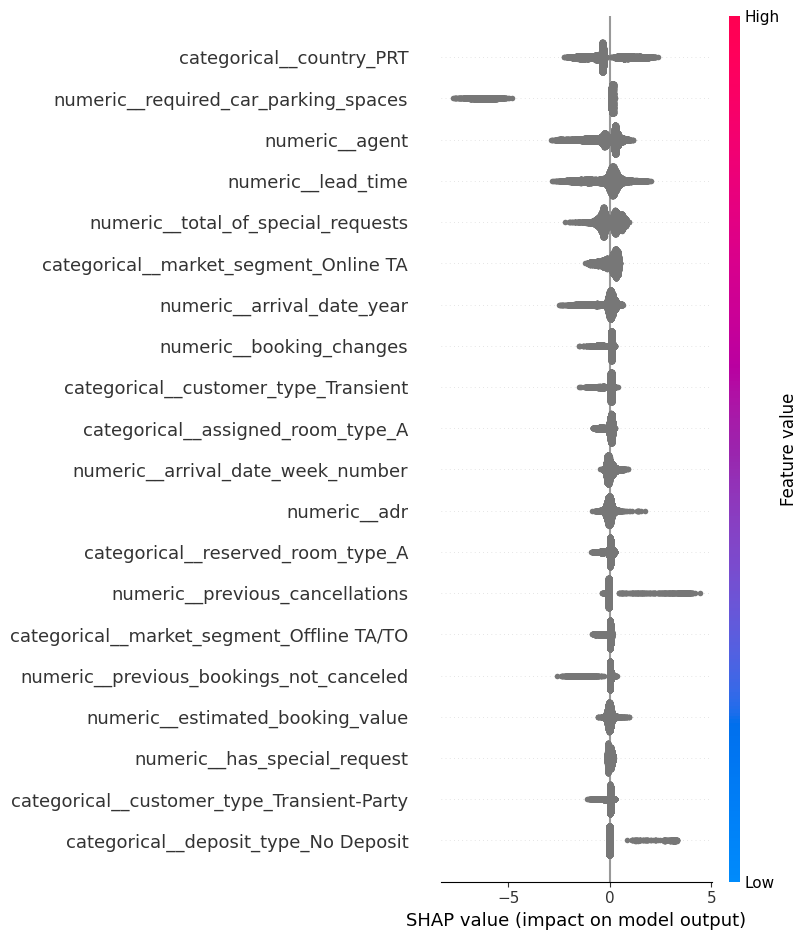

In [68]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    max_display=20
)

In [69]:
feature_names = final_model.named_steps[
    "preprocessor"
].get_feature_names_out()

print("Number of features:", len(feature_names))

Number of features: 260


In [70]:
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": np.abs(shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "importance",
    ascending=False
)

print("Top 20 cancellation drivers:")
display(shap_importance.head(20))

Top 20 cancellation drivers:


,feature,importance
178,categorical__country_PRT,0.840541
17,numeric__required_car_parking_spaces,0.640617
13,numeric__agent,0.521985
0,numeric__lead_time,0.487464
18,numeric__total_of_special_requests,0.420155
226,categorical__market_segment_Online TA,0.305730
1,numeric__arrival_date_year,0.233624
12,numeric__booking_changes,0.158651
258,categorical__customer_type_Transient,0.144573
242,categorical__assigned_room_type_A,0.122108


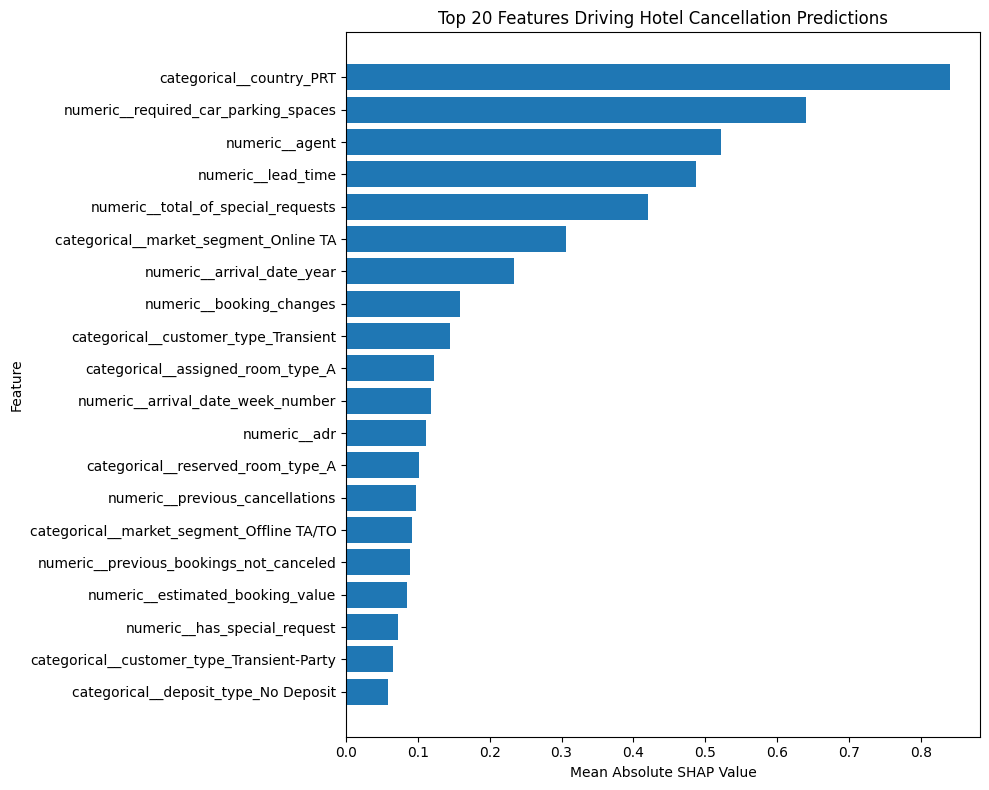

In [71]:
top_features = shap_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 20 Features Driving Hotel Cancellation Predictions")

plt.tight_layout()
plt.show()

In [72]:
feature_report = shap_importance.head(20).copy()

feature_report["feature"] = (
    feature_report["feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
    .str.replace("_", " ", regex=False)
    .str.title()
)

feature_report = feature_report.reset_index(drop=True)

display(feature_report)

,feature,importance
0,Country Prt,0.840541
1,Required Car Parking Spaces,0.640617
2,Agent,0.521985
3,Lead Time,0.487464
4,Total Of Special Requests,0.420155
5,Market Segment Online Ta,0.305730
6,Arrival Date Year,0.233624
7,Booking Changes,0.158651
8,Customer Type Transient,0.144573
9,Assigned Room Type A,0.122108


In [73]:
risk_df = X_test.copy()

risk_df["actual_cancellation"] = y_test.values

risk_df["cancellation_probability"] = final_probabilities

risk_df["predicted_cancellation"] = (
    final_probabilities >= final_threshold
).astype(int)

print("Risk dataset created!")
print(risk_df.shape)

Risk dataset created!
(17349, 41)


In [74]:
def risk_category(probability):
    if probability < 0.20:
        return "Low"
    elif probability < 0.40:
        return "Medium"
    elif probability < 0.70:
        return "High"
    else:
        return "Critical"

risk_df["risk_category"] = (
    risk_df["cancellation_probability"]
    .apply(risk_category)
)

risk_df[
    [
        "cancellation_probability",
        "risk_category"
    ]
].head(10)

,cancellation_probability,risk_category
7925,0.908324,Critical
105184,0.000736,Low
95916,0.087680,Low
72724,0.606873,High
32613,0.000095,Low
90487,0.028926,Low
16726,0.000103,Low
105449,0.001858,Low
49242,0.529337,High
10415,0.905529,Critical


In [75]:
risk_df["revenue_at_risk"] = (
    risk_df["estimated_booking_value"]
    * risk_df["cancellation_probability"]
)

print("Revenue-at-risk calculated!")

Revenue-at-risk calculated!


In [76]:
top_risk_bookings = risk_df.sort_values(
    "revenue_at_risk",
    ascending=False
)

display(
    top_risk_bookings[
        [
            "hotel",
            "lead_time",
            "adr",
            "total_nights",
            "estimated_booking_value",
            "cancellation_probability",
            "risk_category",
            "revenue_at_risk"
        ]
    ].head(20)
)

,hotel,lead_time,adr,total_nights,estimated_booking_value,cancellation_probability,risk_category,revenue_at_risk
48515,City Hotel,35,5400.00,1,5400.00,0.988332,Critical,5336.992013
60780,City Hotel,66,147.90,28,4141.20,0.960949,Critical,3979.483742
62583,City Hotel,123,140.00,30,4200.00,0.904542,Critical,3799.076521
13350,Resort Hotel,238,297.38,13,3865.94,0.962767,Critical,3722.000627
56943,City Hotel,20,265.93,14,3723.02,0.975850,Critical,3633.107462
7025,Resort Hotel,203,204.44,18,3679.92,0.961734,Critical,3539.102854
63054,City Hotel,9,133.36,29,3867.44,0.836077,Critical,3233.478227
57099,City Hotel,15,236.14,14,3305.96,0.965271,Critical,3191.145726
13760,Resort Hotel,237,293.60,10,2936.00,0.983073,Critical,2886.303367
13703,Resort Hotel,181,205.14,14,2871.96,0.977603,Critical,2807.637620


In [77]:
total_revenue_at_risk = (
    risk_df["revenue_at_risk"].sum()
)

total_booking_value = (
    risk_df["estimated_booking_value"].sum()
)

print(
    "Total booking value: ₹",
    round(total_booking_value, 2)
)

print(
    "Expected revenue at risk: ₹",
    round(total_revenue_at_risk, 2)
)

print(
    "Risk percentage:",
    round(
        100 * total_revenue_at_risk /
        total_booking_value,
        2
    ),
    "%"
)

Total booking value: ₹ 6921357.85
Expected revenue at risk: ₹ 2303555.87
Risk percentage: 33.28 %


In [78]:
# ============================================
# HOTEL CANCELLATION DECISION ENGINE
# ============================================

def recommended_action(row):

    probability = row["cancellation_probability"]
    revenue = row["revenue_at_risk"]

    # Critical risk + high revenue exposure
    if probability >= 0.70 and revenue >= risk_df["revenue_at_risk"].quantile(0.75):
        return "URGENT: Priority intervention"

    # Critical risk
    elif probability >= 0.70:
        return "Contact guest / confirmation strategy"

    # High risk
    elif probability >= 0.40:
        return "Monitor and consider proactive confirmation"

    # Medium risk
    elif probability >= 0.20:
        return "Monitor booking"

    # Low risk
    else:
        return "Normal monitoring"


risk_df["recommended_action"] = risk_df.apply(
    recommended_action,
    axis=1
)

print("Decision engine created!")

Decision engine created!


In [79]:
risk_df["priority_score"] = (
    risk_df["cancellation_probability"]
    * risk_df["estimated_booking_value"]
)

risk_df["priority_score"] = (
    risk_df["priority_score"]
    .round(2)
)

print("Priority score created!")

Priority score created!


In [80]:
priority_bookings = risk_df.sort_values(
    "priority_score",
    ascending=False
).copy()

columns_to_show = [
    "hotel",
    "lead_time",
    "adr",
    "total_nights",
    "estimated_booking_value",
    "cancellation_probability",
    "risk_category",
    "revenue_at_risk",
    "priority_score",
    "recommended_action"
]

display(
    priority_bookings[
        columns_to_show
    ].head(20)
)

,hotel,lead_time,adr,total_nights,estimated_booking_value,cancellation_probability,risk_category,revenue_at_risk,priority_score,recommended_action
48515,City Hotel,35,5400.00,1,5400.00,0.988332,Critical,5336.992013,5336.99,URGENT: Priority intervention
60780,City Hotel,66,147.90,28,4141.20,0.960949,Critical,3979.483742,3979.48,URGENT: Priority intervention
62583,City Hotel,123,140.00,30,4200.00,0.904542,Critical,3799.076521,3799.08,URGENT: Priority intervention
13350,Resort Hotel,238,297.38,13,3865.94,0.962767,Critical,3722.000627,3722.00,URGENT: Priority intervention
56943,City Hotel,20,265.93,14,3723.02,0.975850,Critical,3633.107462,3633.11,URGENT: Priority intervention
7025,Resort Hotel,203,204.44,18,3679.92,0.961734,Critical,3539.102854,3539.10,URGENT: Priority intervention
63054,City Hotel,9,133.36,29,3867.44,0.836077,Critical,3233.478227,3233.48,URGENT: Priority intervention
57099,City Hotel,15,236.14,14,3305.96,0.965271,Critical,3191.145726,3191.15,URGENT: Priority intervention
13760,Resort Hotel,237,293.60,10,2936.00,0.983073,Critical,2886.303367,2886.30,URGENT: Priority intervention
13703,Resort Hotel,181,205.14,14,2871.96,0.977603,Critical,2807.637620,2807.64,URGENT: Priority intervention


In [81]:
risk_distribution = (
    risk_df["risk_category"]
    .value_counts()
    .reindex(
        ["Low", "Medium", "High", "Critical"],
        fill_value=0
    )
)

display(risk_distribution)

,count
risk_category,
Low,9778
Medium,2243
High,2719
Critical,2609


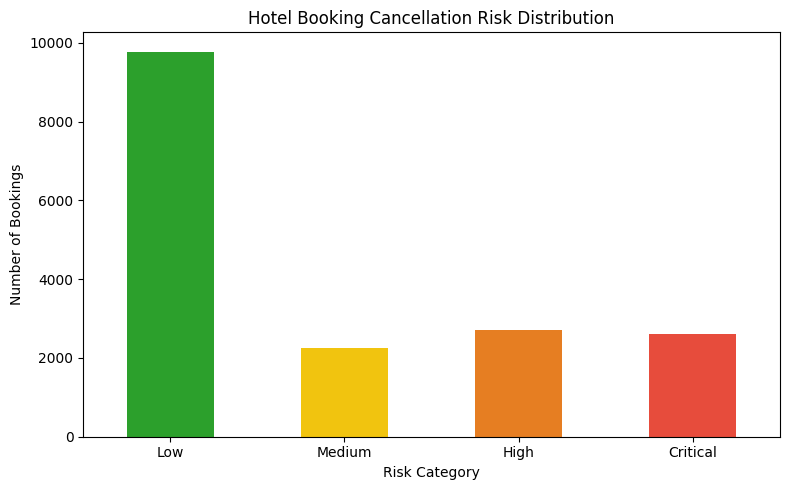

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

colors = [
    "#2ca02c",
    "#f1c40f",
    "#e67e22",
    "#e74c3c"
]

risk_distribution.plot(
    kind="bar",
    color=colors
)

plt.title("Hotel Booking Cancellation Risk Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [83]:
revenue_by_risk = (
    risk_df
    .groupby("risk_category")["revenue_at_risk"]
    .sum()
    .reindex(
        ["Low", "Medium", "High", "Critical"]
    )
)

display(revenue_by_risk)

,revenue_at_risk
risk_category,
Low,1.440306e+05
Medium,2.697534e+05
High,6.797194e+05
Critical,1.210053e+06


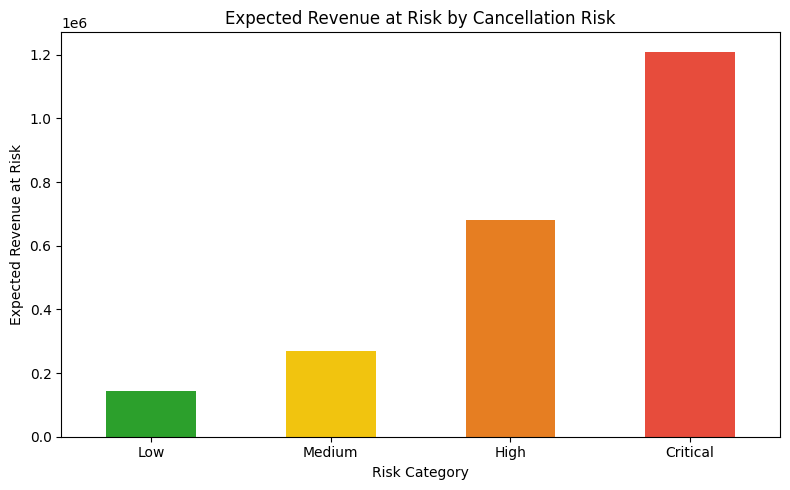

In [84]:
plt.figure(figsize=(8, 5))

revenue_by_risk.plot(
    kind="bar",
    color=colors
)

plt.title("Expected Revenue at Risk by Cancellation Risk")
plt.xlabel("Risk Category")
plt.ylabel("Expected Revenue at Risk")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [85]:
# ============================================
# DASHBOARD SUMMARY
# ============================================

total_bookings = len(risk_df)

actual_cancellations = risk_df["actual_cancellation"].sum()

actual_cancellation_rate = (
    actual_cancellations / total_bookings * 100
)

high_risk_count = risk_df[
    risk_df["risk_category"].isin(["High", "Critical"])
].shape[0]

critical_count = risk_df[
    risk_df["risk_category"] == "Critical"
].shape[0]

total_revenue_at_risk = risk_df[
    "revenue_at_risk"
].sum()

print("============================================")
print(" HOTEL CANCELLATION RISK DASHBOARD")
print("============================================")
print(f"Total bookings          : {total_bookings:,}")
print(f"Actual cancellations    : {actual_cancellations:,}")
print(f"Cancellation rate       : {actual_cancellation_rate:.2f}%")
print(f"High/Critical bookings  : {high_risk_count:,}")
print(f"Critical bookings       : {critical_count:,}")
print(f"Revenue at risk         : ₹{total_revenue_at_risk:,.2f}")
print(f"Final model             : {final_model_name}")
print(f"Decision threshold      : {final_threshold:.2f}")

 HOTEL CANCELLATION RISK DASHBOARD
Total bookings          : 17,349
Actual cancellations    : 4,799
Cancellation rate       : 27.66%
High/Critical bookings  : 5,328
Critical bookings       : 2,609
Revenue at risk         : ₹2,303,555.87
Final model             : Tuned XGBoost
Decision threshold      : 0.32


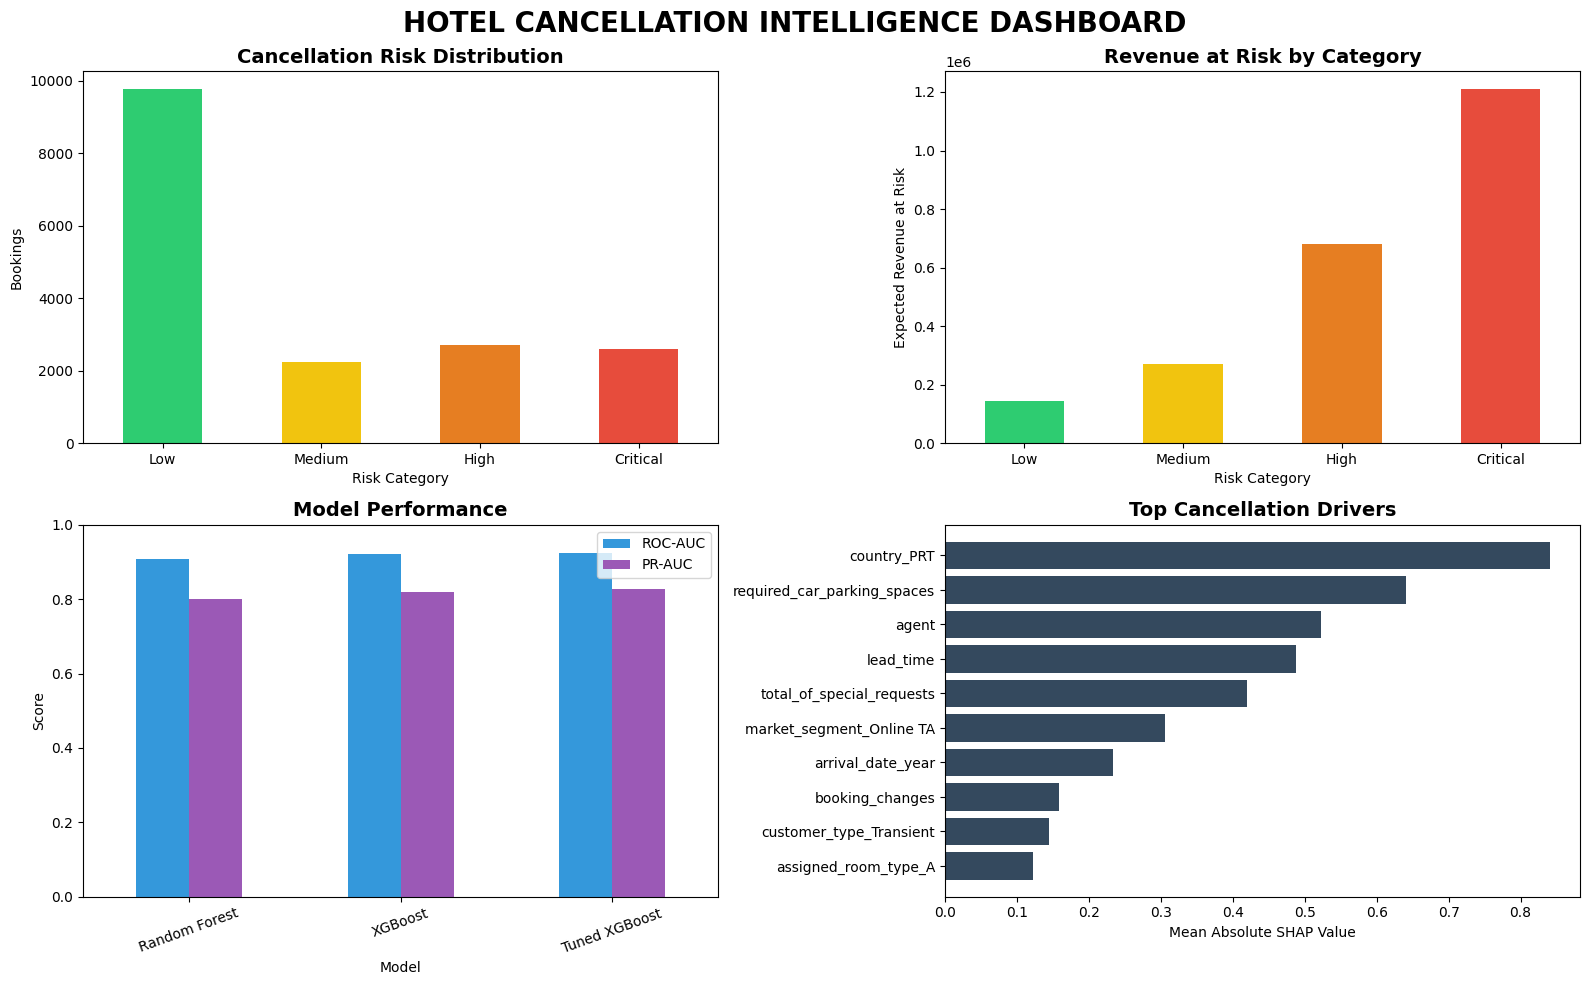

In [86]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10)
)

# --------------------------------------------
# 1. Risk distribution
# --------------------------------------------

risk_distribution.plot(
    kind="bar",
    ax=axes[0, 0],
    color=[
        "#2ecc71",
        "#f1c40f",
        "#e67e22",
        "#e74c3c"
    ]
)

axes[0, 0].set_title(
    "Cancellation Risk Distribution",
    fontsize=14,
    fontweight="bold"
)

axes[0, 0].set_xlabel("Risk Category")
axes[0, 0].set_ylabel("Bookings")
axes[0, 0].tick_params(axis="x", rotation=0)


# --------------------------------------------
# 2. Revenue at risk
# --------------------------------------------

revenue_by_risk.plot(
    kind="bar",
    ax=axes[0, 1],
    color=[
        "#2ecc71",
        "#f1c40f",
        "#e67e22",
        "#e74c3c"
    ]
)

axes[0, 1].set_title(
    "Revenue at Risk by Category",
    fontsize=14,
    fontweight="bold"
)

axes[0, 1].set_xlabel("Risk Category")
axes[0, 1].set_ylabel("Expected Revenue at Risk")
axes[0, 1].tick_params(axis="x", rotation=0)


# --------------------------------------------
# 3. Model comparison
# --------------------------------------------

model_plot = model_comparison[
    ["Model", "ROC-AUC", "PR-AUC"]
].set_index("Model")

model_plot.plot(
    kind="bar",
    ax=axes[1, 0],
    color=["#3498db", "#9b59b6"]
)

axes[1, 0].set_title(
    "Model Performance",
    fontsize=14,
    fontweight="bold"
)

axes[1, 0].set_ylabel("Score")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].tick_params(axis="x", rotation=20)


# --------------------------------------------
# 4. Top cancellation drivers
# --------------------------------------------

top10 = shap_importance.head(10).copy()

top10["feature"] = (
    top10["feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

axes[1, 1].barh(
    top10["feature"][::-1],
    top10["importance"][::-1],
    color="#34495e"
)

axes[1, 1].set_title(
    "Top Cancellation Drivers",
    fontsize=14,
    fontweight="bold"
)

axes[1, 1].set_xlabel(
    "Mean Absolute SHAP Value"
)

plt.suptitle(
    "HOTEL CANCELLATION INTELLIGENCE DASHBOARD",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [87]:
top10_priority = priority_bookings[
    [
        "hotel",
        "lead_time",
        "total_nights",
        "estimated_booking_value",
        "cancellation_probability",
        "risk_category",
        "revenue_at_risk",
        "recommended_action"
    ]
].head(10)

display(top10_priority)

,hotel,lead_time,total_nights,estimated_booking_value,cancellation_probability,risk_category,revenue_at_risk,recommended_action
48515,City Hotel,35,1,5400.00,0.988332,Critical,5336.992013,URGENT: Priority intervention
60780,City Hotel,66,28,4141.20,0.960949,Critical,3979.483742,URGENT: Priority intervention
62583,City Hotel,123,30,4200.00,0.904542,Critical,3799.076521,URGENT: Priority intervention
13350,Resort Hotel,238,13,3865.94,0.962767,Critical,3722.000627,URGENT: Priority intervention
56943,City Hotel,20,14,3723.02,0.975850,Critical,3633.107462,URGENT: Priority intervention
7025,Resort Hotel,203,18,3679.92,0.961734,Critical,3539.102854,URGENT: Priority intervention
63054,City Hotel,9,29,3867.44,0.836077,Critical,3233.478227,URGENT: Priority intervention
57099,City Hotel,15,14,3305.96,0.965271,Critical,3191.145726,URGENT: Priority intervention
13760,Resort Hotel,237,10,2936.00,0.983073,Critical,2886.303367,URGENT: Priority intervention
13703,Resort Hotel,181,14,2871.96,0.977603,Critical,2807.637620,URGENT: Priority intervention


In [88]:
output_file = "hotel_cancellation_risk_predictions.csv"

risk_df.to_csv(
    output_file,
    index=False
)

print("Saved:", output_file)

Saved: hotel_cancellation_risk_predictions.csv


In [89]:
from google.colab import files

files.download(
    "hotel_cancellation_risk_predictions.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [90]:
def predict_booking_risk(booking):

    booking_df = pd.DataFrame([booking])

    probability = final_model.predict_proba(
        booking_df
    )[:, 1][0]

    risk = risk_category(probability)

    booking_value = (
        booking_df["estimated_booking_value"].iloc[0]
    )

    revenue_risk = (
        booking_value * probability
    )

    if probability >= 0.70:
        action = "Urgent intervention"
    elif probability >= 0.40:
        action = "Proactive confirmation"
    elif probability >= 0.20:
        action = "Monitor booking"
    else:
        action = "Normal monitoring"

    return {
        "Cancellation Probability": round(
            probability, 4
        ),
        "Risk Category": risk,
        "Booking Value": round(
            booking_value, 2
        ),
        "Revenue at Risk": round(
            revenue_risk, 2
        ),
        "Recommended Action": action
    }

In [91]:
print("Final model:", final_model_name)
print("Final threshold:", final_threshold)
print("Prediction function is ready!")

Final model: Tuned XGBoost
Final threshold: 0.3200000000000001
Prediction function is ready!


In [92]:
sample_booking = X_test.iloc[0].copy()

sample_booking

,7925
hotel,Resort Hotel
lead_time,315
arrival_date_year,2016
arrival_date_month,September
arrival_date_week_number,36
arrival_date_day_of_month,2
stays_in_weekend_nights,2
stays_in_week_nights,5
adults,2
children,0.0


In [94]:
sample_result = predict_booking_risk(
    sample_booking.to_dict()
)

print("====================================")
print(" HOTEL BOOKING RISK PREDICTION")
print("====================================")

for key, value in sample_result.items():
    print(f"{key}: {value}")

 HOTEL BOOKING RISK PREDICTION
Cancellation Probability: 0.90829998254776
Risk Category: Critical
Booking Value: 604.8
Revenue at Risk: 549.35
Recommended Action: Urgent intervention


In [ ]:
sample_bookings = X_test.iloc[:10].copy()

sample_probabilities = final_model.predict_proba(
    sample_bookings
)[:, 1]

demo_results = pd.DataFrame({
    "Cancellation Probability": sample_probabilities
})

demo_results["Risk Category"] = (
    demo_results["Cancellation Probability"]
    .apply(risk_category)
)

demo_results["Booking Value"] = (
    sample_bookings["estimated_booking_value"]
    .values
)

demo_results["Revenue at Risk"] = (
    demo_results["Cancellation Probability"]
    * demo_results["Booking Value"]
)

demo_results["Recommended Action"] = (
    demo_results["Cancellation Probability"]
    .apply(
        lambda p:
        "Urgent intervention" if p >= 0.70
        else "Proactive confirmation" if p >= 0.40
        else "Monitor booking" if p >= 0.20
        else "Normal monitoring"
    )
)

display(
    demo_results.round(2)
)

In [95]:
final_results = pd.DataFrame({
    "Actual": y_test.values,
    "Cancellation Probability": final_probabilities,
    "Predicted": final_predictions
})

final_results["Risk Category"] = (
    final_results["Cancellation Probability"]
    .apply(risk_category)
)

final_results.head(20)

,Actual,Cancellation Probability,Predicted,Risk Category
0,1,0.908324,1,Critical
1,0,0.000736,0,Low
2,0,0.087680,0,Low
3,1,0.606873,1,High
4,0,0.000095,0,Low
5,0,0.028926,0,Low
6,0,0.000103,0,Low
7,0,0.001858,0,Low
8,1,0.529337,1,High
9,1,0.905529,1,Critical


In [96]:
final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Score": [
        accuracy_score(y_test, final_predictions),
        precision_score(
            y_test,
            final_predictions
        ),
        recall_score(
            y_test,
            final_predictions
        ),
        f1_score(
            y_test,
            final_predictions
        ),
        roc_auc_score(
            y_test,
            final_probabilities
        ),
        average_precision_score(
            y_test,
            final_probabilities
        )
    ]
})

final_metrics["Score"] = (
    final_metrics["Score"].round(4)
)

display(final_metrics)

,Metric,Score
0,Accuracy,0.8427
1,Precision,0.6699
2,Recall,0.8504
3,F1 Score,0.7494
4,ROC-AUC,0.9238
5,PR-AUC,0.8267


In [97]:
import joblib

joblib.dump(
    final_model,
    "hotel_cancellation_final_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [98]:
from google.colab import files

files.download(
    "hotel_cancellation_final_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [99]:
project_summary = {
    "final_model": final_model_name,
    "threshold": float(final_threshold),
    "roc_auc": float(
        roc_auc_score(
            y_test,
            final_probabilities
        )
    ),
    "pr_auc": float(
        average_precision_score(
            y_test,
            final_probabilities
        )
    ),
    "accuracy": float(
        accuracy_score(
            y_test,
            final_predictions
        )
    ),
    "precision": float(
        precision_score(
            y_test,
            final_predictions
        )
    ),
    "recall": float(
        recall_score(
            y_test,
            final_predictions
        )
    ),
    "f1": float(
        f1_score(
            y_test,
            final_predictions
        )
    )
}

project_summary

{'final_model': 'Tuned XGBoost',
 'threshold': 0.3200000000000001,
 'roc_auc': 0.9238267600570835,
 'pr_auc': 0.8266723909729606,
 'accuracy': 0.8426998674275175,
 'precision': 0.6698949441891004,
 'recall': 0.8503854969785372,
 'f1': 0.74942613166835}

In [100]:
import joblib

joblib.dump(
    final_model,
    "/content/hotelguard_final_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [101]:
from google.colab import files

files.download(
    "/content/hotelguard_final_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [102]:
import sklearn
import xgboost
import joblib

print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("Joblib:", joblib.__version__)

scikit-learn: 1.6.1
XGBoost: 3.4.0
Joblib: 1.5.3


In [3]:
from google.colab import files

uploaded = files.upload()

Saving hotel_bookings.csv to hotel_bookings.csv


In [4]:
df = pd.read_csv("hotel_bookings.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (119390, 32)
